## Today's topics

- Conditional Probability
- Intuition of Conditional Probability Formula
- Independent vs. Dependent vs. Mutually Exclusive Events
- Bayes Theorem

---


## 1️⃣ Conditional Probability

Conditional probability measures the likelihood of an event **A**,  
given that another event **B** has occurred.

Formula:
**P(A | B) = P(A ∩ B) / P(B)**


In [1]:

import pandas as pd
import numpy as np

data = {
    "Gender": np.random.choice(["Male", "Female"], size=100),
    "Purchased": np.random.choice(["Yes", "No"], size=100, p=[0.6, 0.4])
}

df = pd.DataFrame(data)
df


,Gender,Purchased
0,Female,Yes
1,Female,No
2,Male,No
3,Male,Yes
4,Male,Yes
...,...,...
95,Female,No
96,Male,No
97,Female,Yes
98,Female,Yes


In [2]:
total = len(df)
total

100

In [3]:
# Marginal Probabailities: Individual counts
female_count = len(df[df['Gender'] == 'Female'])
male_count   = len(df[df['Gender'] == 'Male'])

yes_count = len(df[df['Purchased'] == 'Yes'])
no_count  = len(df[df['Purchased'] == 'No'])

# Joint Probabilities: Joint counts
female_yes = len(df[(df['Gender'] == 'Female') & (df['Purchased'] == 'Yes')])
female_no  = len(df[(df['Gender'] == 'Female') & (df['Purchased'] == 'No')])

male_yes = len(df[(df['Gender'] == 'Male') & (df['Purchased'] == 'Yes')])
male_no  = len(df[(df['Gender'] == 'Male') & (df['Purchased'] == 'No')])

female_count, male_count, yes_count, no_count

(42, 58, 58, 42)

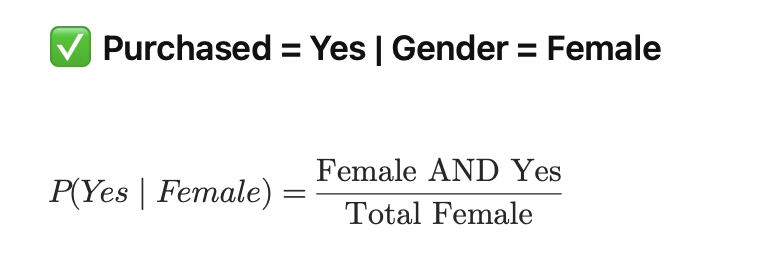

In [4]:
# Conditional Probability
# Final probability of Purchased = Yes | Gender = Female

p_yes_given_female = female_yes / female_count
p_yes_given_female

0.7142857142857143

In [5]:
# Conditional Probability
# Final probability of Purchased = No | Gender = Female

p_no_given_female = female_no / female_count
p_no_given_female

0.2857142857142857

In [6]:
# Conditional Probability: Gender GIVEN Purchased

p_female_yes = len(df[(df['Gender']=='Female') & (df['Purchased']=='Yes')])
p_female = len(df[df['Gender']=='Female'])

p_female_given_purchased = p_female_yes / p_female
p_female_given_purchased

0.7142857142857143

In [7]:
# Just check

p_yes_given_female + p_no_given_female

1.0

In [8]:
# Automatic pandas way

cond_prob = pd.crosstab(df['Gender'], df['Purchased'], normalize='index')
cond_prob

Purchased,No,Yes
Gender,,
Female,0.285714,0.714286
Male,0.517241,0.482759



## 2️⃣ Types of Events



### Independent Events
Occurrence of one event does not affect the other.

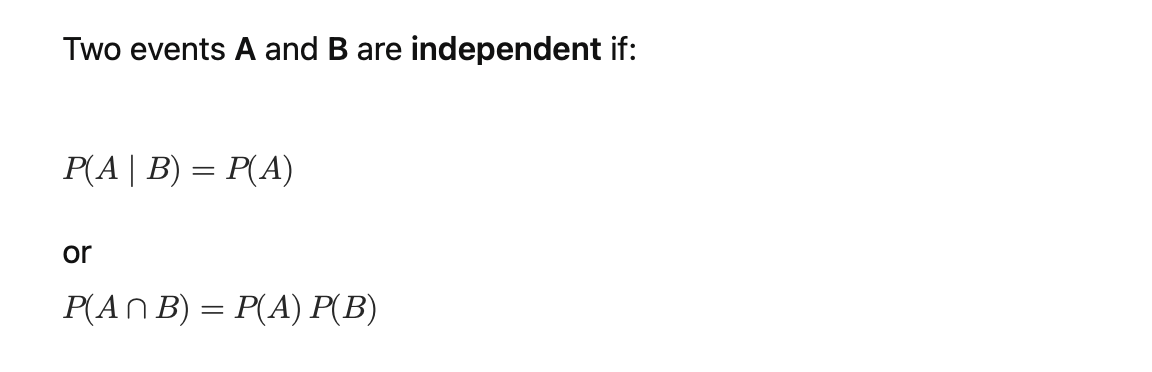


In [9]:
P_yes = yes_count / total
P_female = female_count / total
P_yes_and_female = female_yes / total

P_yes, P_female, P_yes_and_female

# Independency check

if P_yes_and_female == P_yes * P_female:
  print("Events are independent")
else:
  print("dependent")


dependent



### Dependent Events
Occurrence of one event affects the other.

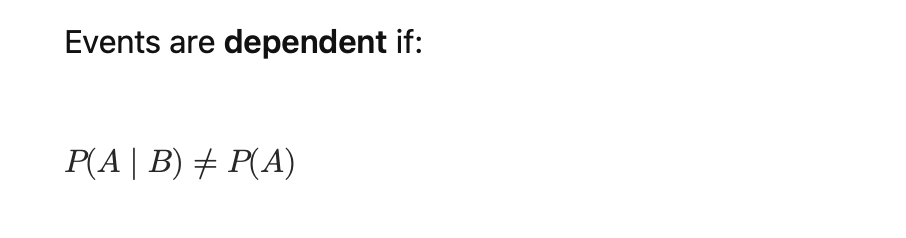


In [10]:
# Dependent events check

p_yes_given_female, P_yes

(0.7142857142857143, 0.58)

In [11]:
p_yes_given_female != P_yes

True

In [12]:

# Card drawing example
p_ace_initial = 4 / 52
p_ace_after_ace_drawn = 3 / 51

p_ace_initial, p_ace_after_ace_drawn


(0.07692307692307693, 0.058823529411764705)


### Mutually Exclusive Events
Two events cannot happen together.


In [13]:
male_and_female = len(df[(df['Gender'] == 'Male') & (df['Gender'] == 'Female')])

male_and_female

0

In [14]:

# Rolling a dice: 2 and 5 cannot occur together
p_intersection = 0
p_intersection


0


## 3️⃣ Bayes’ Theorem



Bayes' theorem reverses conditional probability:

**P(A | B) = [P(B | A) × P(A)] / P(B)**


## Conditional Probability

By definition:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

Similarly,

$$
P(B \mid A) = \frac{P(A \cap B)}{P(A)}
$$

## Joint Probability Relationship

From conditional probability:

$$
P(A \cap B) = P(A \mid B) \cdot P(B)
$$

and

$$
P(A \cap B) = P(B \mid A) \cdot P(A)
$$

## Derivation of Bayes' Theorem

Since both expressions represent $P(A \cap B)$:

$$
P(A \mid B) \cdot P(B) = P(B \mid A) \cdot P(A)
$$

Rearranging:

$$
\boxed{P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}}
$$

## Interpretation of Terms

- **Prior** → $P(A)$
- **Likelihood** → $P(B \mid A)$
- **Marginal Probability** → $P(B)$
- **Posterior** → $P(A \mid B)$

## **Example 1: Playing Cards**

**Question:**

What is the probability that a card is a **King**, given that it is a **Face card**?

$$
P(\text{King} \mid \text{Face}) = \frac{P(\text{Face} \mid \text{King}) \cdot P(\text{King})}{P(\text{Face})}
$$

In [15]:
# Total cards in a deck
total_cards = 52

# Counts
kings = 4
face_cards = 12

# Probabilities
P_king = kings / total_cards
P_face = face_cards / total_cards
P_face_given_king = 1  # every king is a face card

# Bayes Theorem
P_king_given_face = (P_face_given_king * P_king) / P_face
P_king_given_face

0.3333333333333333

## Final Result

$$
P(\text{King} \mid \text{Face}) = \frac{4/52}{12/52} = \frac{1}{3}
$$

**Conclusion:**

> Given that the card is a face card, the probability that it is a King is **1/3**.

## **Example 2: Gender and Purchased**

**Question:**

What is the probability that a gender is a **Female**, given that she has **Purchased** something?

In [ ]:
total = len(df)

# Marginal Probabailities: Individual counts
female_count = len(df[df['Gender'] == 'Female'])
male_count   = len(df[df['Gender'] == 'Male'])

yes_count = len(df[df['Purchased'] == 'Yes'])
no_count  = len(df[df['Purchased'] == 'No'])

# Joint Probabilities: Joint counts
female_yes = len(df[(df['Gender'] == 'Female') & (df['Purchased'] == 'Yes')])
female_no  = len(df[(df['Gender'] == 'Female') & (df['Purchased'] == 'No')])

male_yes = len(df[(df['Gender'] == 'Male') & (df['Purchased'] == 'Yes')])
male_no  = len(df[(df['Gender'] == 'Male') & (df['Purchased'] == 'No')])


**Define Events**

A = Gender = Female

B = Purchased = Yes

We want:
**P(Female | Yes)**

In [16]:
# P(B | A) = P(Yes | Female)
P_yes_given_female = female_yes / female_count

# P(A) = P(Female)
P_female = female_count / total

# P(B) = P(Yes)
P_yes = yes_count / total

P_yes_given_female, P_female, P_yes

(0.7142857142857143, 0.42, 0.58)

In [17]:
# Apply Bayes’ Formula (Step-by-Step)

P_female_given_yes_bayes = (P_yes_given_female * P_female) / P_yes
P_female_given_yes_bayes

0.5172413793103449

In [18]:
# Direct Manual Check (Validation)

P_female_given_yes_direct = female_yes / yes_count
P_female_given_yes_direct

0.5172413793103449

In [19]:
# Compare Bayes vs Direct

P_female_given_yes_bayes == P_female_given_yes_direct

True

In [20]:
# One More Bayes Example (Reverse Gender)
# P(Male | Purchased = Yes)

# P(Yes | Male)
P_yes_given_male = male_yes / male_count

# P(Male)
P_male = male_count / total

P_male_given_yes_bayes = (P_yes_given_male * P_male) / P_yes
P_male_given_yes_bayes

0.48275862068965514

In [21]:
# Direct Check

male_yes / yes_count

0.4827586206896552

In [22]:
{
    "P(Female | Yes) [Bayes]": P_female_given_yes_bayes,
    "P(Male | Yes) [Bayes]": P_male_given_yes_bayes,
    "Sum Check": P_female_given_yes_bayes + P_male_given_yes_bayes
}

{'P(Female | Yes) [Bayes]': 0.5172413793103449,
 'P(Male | Yes) [Bayes]': 0.48275862068965514,
 'Sum Check': 1.0}


## 📝 Practice Questions

1. Define conditional probability.
2. Why conditional probability is important?
3. Difference between independent and dependent events.
4. Explain Bayes' theorem in your own words.



## 📌 Mini Assignment

Spam filter case study:
- 20% emails are spam
- P(Detected | Spam) = 0.95
- P(Detected | Not Spam) = 0.10

Calculate P(Spam | Detected).
